In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [2]:
import matplotlib.pyplot as plt

In [3]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

In [4]:
from statsmodels.stats.anova import anova_lm

In [5]:
rng = np.random.default_rng(1)

In [6]:
x = rng.normal(size=100)

In [7]:
eps = rng.normal(loc=0, scale=np.sqrt(0.25), size=100)
eps

array([-3.25640506e-01,  4.31222398e-01, -6.27960420e-02,  3.34576620e-01,
        6.09421803e-01,  1.91464791e-01, -4.37860572e-01, -7.57159316e-01,
        8.76692059e-01, -5.56460966e-02, -3.44282474e-01,  7.21285440e-02,
       -9.57056652e-02,  4.26071132e-01,  1.69640912e-02,  6.87479181e-03,
       -3.57289861e-01,  2.34784049e-01, -5.16933361e-01,  3.32944720e-01,
        7.61968756e-01, -7.62343019e-01, -1.23311462e+00,  3.08439378e-01,
        1.27394891e+00, -5.00462424e-01, -6.25347879e-01,  2.94484467e-01,
       -4.20360795e-01, -2.53012742e-01, -1.74058733e-01,  2.66001043e-01,
       -2.02651181e-01,  1.38941420e-01, -8.82666294e-02, -4.22335552e-01,
       -1.59913129e-01, -4.75199833e-01,  3.25749293e-03, -5.61933114e-01,
       -5.46447185e-01,  7.28480908e-01, -2.65921102e-02, -2.69510127e-02,
        2.55768210e-01, -2.10428501e-01, -1.14267684e-01,  2.12574368e-01,
        1.41207921e-01, -5.79648363e-01,  4.16671298e-01, -2.95217472e-01,
       -5.28039475e-01, -

In [8]:
# larger value of eps 
eps2 = rng.normal(loc=0, scale=np.sqrt(0.5), size=100)

In [9]:
# smaller value of eps
eps3 = rng.normal(loc=0, scale=np.sqrt(0.1), size=100)

In [10]:
y = -1 + 0.5*x + eps
y2 = -1 + 0.5*x + eps2
y3 = -1 + 0.5*x + eps3
y

array([-1.15284841, -0.15796853, -0.8975775 , -1.317002  ,  0.06209974,
       -0.58534792, -1.70633719, -1.46660026,  0.05897826, -0.90857985,
       -1.33007135, -0.65451496, -1.46393271, -0.65538384, -1.22409557,
       -0.6937021 , -1.33742881, -0.91144433, -1.90788759, -0.7956514 ,
       -0.23396015, -1.90014447, -1.58608271, -0.18819846, -1.08163233,
       -2.44496905, -1.71273393, -0.91661074, -1.3135393 , -1.14435178,
       -0.11513936, -1.29000934, -1.39145368,  0.16032722, -0.76491513,
       -1.09080387, -1.41691631, -2.29923742, -0.91301013, -1.50742607,
       -2.16012321, -0.61313242, -1.06261395, -1.49932682, -0.79336677,
       -1.16268699, -1.09647457, -1.04057146, -0.56191804, -1.13406489,
       -0.42290455, -1.70433259, -1.16221333, -1.70095754, -0.75569236,
       -0.72224358, -1.13053435, -0.92999378, -2.69328662, -1.1577332 ,
       -0.52316565, -0.98193599, -1.80577152, -1.43793099, -0.55013186,
       -0.90154602,  0.10398973, -0.5156565 , -2.12059873, -0.93

In [11]:
len(y)

100

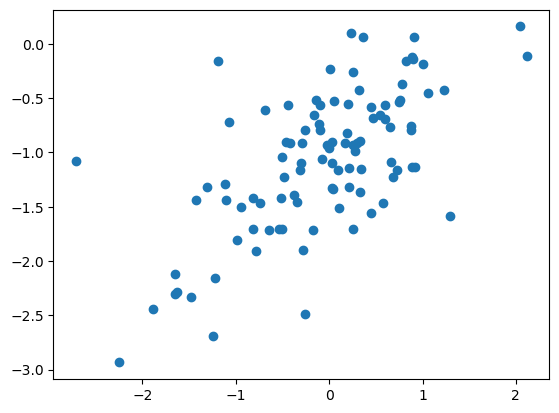

In [12]:
plt.scatter(x, y)

In [13]:
X = pd.DataFrame({"intercept": np.ones(len(y)), "x":x})
model = sm.OLS(y, X)
results = model.fit()
print(summarize(results))
results.conf_int(alpha=0.05)

             coef  std err       t  P>|t|
intercept -1.0380    0.050 -20.647    0.0
x          0.4843    0.059   8.233    0.0


,0,1
intercept,-1.137782,-0.938244
x,0.367565,0.601017


In [14]:
X = pd.DataFrame({"intercept": np.ones(len(y2)), "x":x})
model = sm.OLS(y2, X)
results = model.fit()
print(summarize(results))
results.conf_int(alpha=0.05)

             coef  std err       t  P>|t|
intercept -1.1145    0.065 -17.026    0.0
x          0.4910    0.077   6.411    0.0


,0,1
intercept,-1.244403,-0.984596
x,0.338981,0.642945


In [15]:
X = pd.DataFrame({"intercept": np.ones(len(y3)), "x":x})
model = sm.OLS(y3, X)
results = model.fit()
print(summarize(results))
results.conf_int(alpha=0.05)

             coef  std err       t  P>|t|
intercept -1.0029    0.028 -36.264    0.0
x          0.5465    0.032  16.890    0.0


,0,1
intercept,-1.057778,-0.948014
x,0.482274,0.610693


In [16]:
def abline(ax , b, m, *args , ** kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim ()
    ylim = [m * xlim [0] + b, m * xlim [1] + b]
    ax.plot(xlim , ylim , *args , ** kwargs)

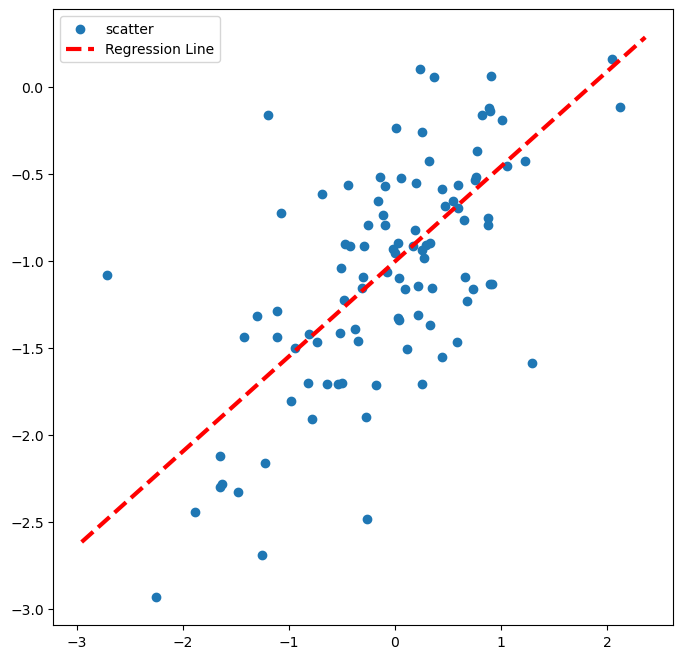

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x, y, label="scatter")
abline(
    ax ,
    results.params.iloc[0],
    results.params.iloc[1],
    'r--', label="Regression Line",
    linewidth =3)
ax.legend()

In [18]:
df = pd.DataFrame({"x" : x, "y" : y, "eps" : eps})
df

,x,y,eps
0,0.345584,-1.152848,-0.325641
1,0.821618,-0.157969,0.431222
2,0.330437,-0.897578,-0.062796
3,-1.303157,-1.317002,0.334577
4,0.905356,0.062100,0.609422
...,...,...,...
95,-2.250854,-2.934161,-0.808734
96,-0.138655,-0.514509,0.554819
97,0.033000,-0.899447,0.084053
98,-1.425349,-1.438472,0.274203


In [19]:
X = MS([poly('x', degree=2)]).fit_transform(df)
X

,intercept,"poly(x, degree=2)[0]","poly(x, degree=2)[1]"
0,1.0,0.049227,-0.036584
1,1.0,0.105129,0.034593
2,1.0,0.047448,-0.038177
3,1.0,-0.144388,0.032896
4,1.0,0.114962,0.051342
...,...,...,...
95,1.0,-0.255678,0.294791
96,1.0,-0.007638,-0.067043
97,1.0,0.012520,-0.061085
98,1.0,-0.158737,0.057565


In [20]:
model2 = sm.OLS(y, X)
results2 = model2.fit()
summarize(results2)

,coef,std err,t,P>|t|
intercept,-1.0737,0.050,-21.326,0.000
"poly(x, degree=2)[0]",4.1240,0.503,8.191,0.000
"poly(x, degree=2)[1]",-0.0261,0.503,-0.052,0.959


In [21]:
anova_lm(results, results2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,98.0,7.439839,0.0,NaN,NaN,NaN
1,97.0,24.585886,1.0,-17.146047,-67.647209,1.0


(h) For smaller noise in the data, the estimated intercept is better but not the estimate of slope.

(i) For larger noise in the data, the estimated intercept is little further from the actual value of the intercept, but the estimated slope is better and very near the exact value.

(j) We observe that the confidence interval gets wider as the variance of eps increase.